<a href="https://colab.research.google.com/github/Fentahun60/Fentahun/blob/main/PHDS_STI_3_round.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [364]:
import pandas as pd
import gdown

# Set pandas options to display all columns and rows without truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.expand_frame_repr', False)

# Extract only the file ID from the Google Drive sharing link
file_id = '1GZbH5OixUi4Qnvx2k8U5ljJwfSAHr4v-'
output_filename = 'All_2.csv'
gdown.download(f'https://drive.google.com/uc?id={file_id}', output_filename, quiet=False)

df = pd.read_csv(output_filename, encoding='latin1', low_memory=False)
print(f"DataFrame Shape: {df.shape}")
display(df.head())

Downloading...
From (original): https://drive.google.com/uc?id=1GZbH5OixUi4Qnvx2k8U5ljJwfSAHr4v-
From (redirected): https://drive.google.com/uc?id=1GZbH5OixUi4Qnvx2k8U5ljJwfSAHr4v-&confirm=t&uuid=022547ba-e7b3-4fac-b683-dce65a843a72
To: /content/All_2.csv
100%|██████████| 152M/152M [00:01<00:00, 79.9MB/s]


DataFrame Shape: (465596, 42)


,caseid,v000,v001,v005,v007,v012,v021,v025,v106,v151,v152,v157,v158,v159,v169a,v171a,v190,v213,v228,v312,v362,v394,v3a13,v463a,v467b,v467c,v467d,v481,v501,v527,v531,v536,v717,v750,v751,v761,v763a,v763b,v763c,v766b,v781,v313
0,1 1 01,AO8,1,771031,2023,21,1,urban,secondary,female,22,not at all,not at all,not at all,no,never,poorer,no or unsure,no,not using,does not intend,no,no,no,not a big problem,not a big problem,not a big problem,no,living with partner,406,inconsistent,not active in last 4 weeks - postpartum abstin...,not working,no,no,NaN,no,no,no,0,no,NaN
1,1 2 02,AO8,1,771031,2023,20,1,urban,primary,male,24,not at all,not at all,not at all,no,never,poorer,no or unsure,no,not using,does not intend,no,no,no,not a big problem,not a big problem,not a big problem,no,living with partner,302,18,not active in last 4 weeks - postpartum abstin...,not working,no,no,no,no,no,no,1,no,NaN
2,1 3 02,AO8,1,771031,2023,21,1,urban,no education,male,27,not at all,not at all,not at all,no,never,poorer,no or unsure,no,not using,use later,yes,no,no,not a big problem,big problem,not a big problem,no,living with partner,weeks: 1,15,active in last 4 weeks,not working,yes,yes,no,no,no,no,1,yes,NaN
3,1 4 02,AO8,1,771031,2023,19,1,urban,no education,male,22,not at all,not at all,not at all,no,never,poorer,no or unsure,no,not using,use later,yes,no,no,not a big problem,big problem,not a big problem,no,living with partner,days: 1,11,active in last 4 weeks,not working,no,no,no,no,no,no,1,no,NaN
4,1 7 01,AO8,1,771031,2023,32,1,urban,no education,female,36,not at all,not at all,not at all,no,never,poorest,no or unsure,no,not using,does not intend,no,no,no,not a big problem,not a big problem,not a big problem,no,no longer living together/separated,days: 1,15,active in last 4 weeks,not working,no,no,no,no,no,no,1,no,NaN


#Missing Values Management

In [365]:
# Identify rows where Maternal_age > 49
over_age_mask = df['v012'] > 49

# Report the number of rows to be removed by country
print("Number of rows to be removed (v012 > 49) by v000:")
print(df[over_age_mask].groupby('v000').size().sort_values(ascending=False))
df.head()

# # Remove the rows from the dataframe
initial_count = len(df)
df = df[~over_age_mask]
final_count = len(df)

# print(f"\nTotal rows removed: {initial_count - final_count}")
print(f"New dataset shape: {df.shape}")

Number of rows to be removed (v012 > 49) by v000:
v000
ML8    3152
GA7    1536
CM7    1150
dtype: int64
New dataset shape: (459758, 42)


In [366]:
df['v000'].value_counts()

,count
v000,
NG8,39050
KE8,32156
CD8,27583
MW8,21587
MD7,18869
UG7,18506
BF8,17659
BU7,17269
ML8,17202


In [367]:
# Inspect the 'v531' column to identify the 'not had sex' category
print("Value counts for 'v531' before filtering:")
print(df['v531'].value_counts(dropna=False))
print("\nUnique values for 'v531' before filtering:")
print(df['v531'].unique())

# Potential categories indicating 'not had sex' in v531.
# This often appears as 0, 97, 98, or specific strings like 'never had sex'.
not_had_sex_categories = ['not had sex', 'Never had sex', 'no sex', '0', 0]

initial_rows = len(df)

# Create a mask to identify rows to remove.
# We convert to string for the .isin check to catch both numeric 0 and string '0'.
df_filtered = df[~df['v531'].astype(str).str.lower().isin([str(cat).lower() for cat in not_had_sex_categories])]

# Report the number of rows removed
removed_rows = initial_rows - len(df_filtered)
print(f"\nNumber of rows removed (v531 is 'not had sex' or 0): {removed_rows}")
print(f"New DataFrame shape: {df_filtered.shape}")

# Report by country (v000) for the filtered DataFrame
print("\nReport by country (v000) after removing 'not had sex' category:")
country_report = df_filtered['v000'].value_counts().sort_index()
display(country_report)

# Display the head of the filtered DataFrame to confirm
print("\nHead of the DataFrame after filtering:")
display(df_filtered.head())

Value counts for 'v531' before filtering:
v531
not had sex     71586
15              67369
16              58604
17              50044
18              47195
14              38127
19              24512
20              22939
13              17576
inconsistent     9039
21               9028
12               8866
22               7324
23               4798
NaN              4245
25               3368
24               3362
11               2637
10               1782
26               1568
8                1221
27               1183
28                931
29                563
30                554
9                 408
31                224
32                193
33                116
35                 94
34                 88
36                 61
38                 40
37                 29
39                 20
42                 14
40                 13
41                 12
43                 10
44                  6
.a                  6
45                  3
Name: count, dtype: int64

Un

,count
v000,
AO8,12835
BF8,15136
BJ7,13975
BU7,12013
CD8,23372
CI8,13214
CM7,11469
ET7,11962
GA7,8421



Head of the DataFrame after filtering:


,caseid,v000,v001,v005,v007,v012,v021,v025,v106,v151,v152,v157,v158,v159,v169a,v171a,v190,v213,v228,v312,v362,v394,v3a13,v463a,v467b,v467c,v467d,v481,v501,v527,v531,v536,v717,v750,v751,v761,v763a,v763b,v763c,v766b,v781,v313
0,1 1 01,AO8,1,771031,2023,21,1,urban,secondary,female,22,not at all,not at all,not at all,no,never,poorer,no or unsure,no,not using,does not intend,no,no,no,not a big problem,not a big problem,not a big problem,no,living with partner,406,inconsistent,not active in last 4 weeks - postpartum abstin...,not working,no,no,NaN,no,no,no,0,no,NaN
1,1 2 02,AO8,1,771031,2023,20,1,urban,primary,male,24,not at all,not at all,not at all,no,never,poorer,no or unsure,no,not using,does not intend,no,no,no,not a big problem,not a big problem,not a big problem,no,living with partner,302,18,not active in last 4 weeks - postpartum abstin...,not working,no,no,no,no,no,no,1,no,NaN
2,1 3 02,AO8,1,771031,2023,21,1,urban,no education,male,27,not at all,not at all,not at all,no,never,poorer,no or unsure,no,not using,use later,yes,no,no,not a big problem,big problem,not a big problem,no,living with partner,weeks: 1,15,active in last 4 weeks,not working,yes,yes,no,no,no,no,1,yes,NaN
3,1 4 02,AO8,1,771031,2023,19,1,urban,no education,male,22,not at all,not at all,not at all,no,never,poorer,no or unsure,no,not using,use later,yes,no,no,not a big problem,big problem,not a big problem,no,living with partner,days: 1,11,active in last 4 weeks,not working,no,no,no,no,no,no,1,no,NaN
4,1 7 01,AO8,1,771031,2023,32,1,urban,no education,female,36,not at all,not at all,not at all,no,never,poorest,no or unsure,no,not using,does not intend,no,no,no,not a big problem,not a big problem,not a big problem,no,no longer living together/separated,days: 1,15,active in last 4 weeks,not working,no,no,no,no,no,no,1,no,NaN


Overall Percentage of Missing Values per Column (filtered to > 0% missing):
v3a13    74.629479
v313     34.316314
v761     29.853097
v751     28.735335
v362     28.139151
v527     19.279056
v481      8.615185
v766b     6.735935
v763b     6.410329
v763c     6.410329
v750      5.786305
v467b     4.939120
v467d     4.939120
v467c     4.939120
v463a     4.938903
v394      4.613079
v536      4.242014
v763a     4.239622
v781      3.318050
v531      0.923312
v190      0.160519
v717      0.012398
v157      0.001740
dtype: float64


Visualizing Percentage of Missing Values by 'v000' and Variable using a Heatmap:


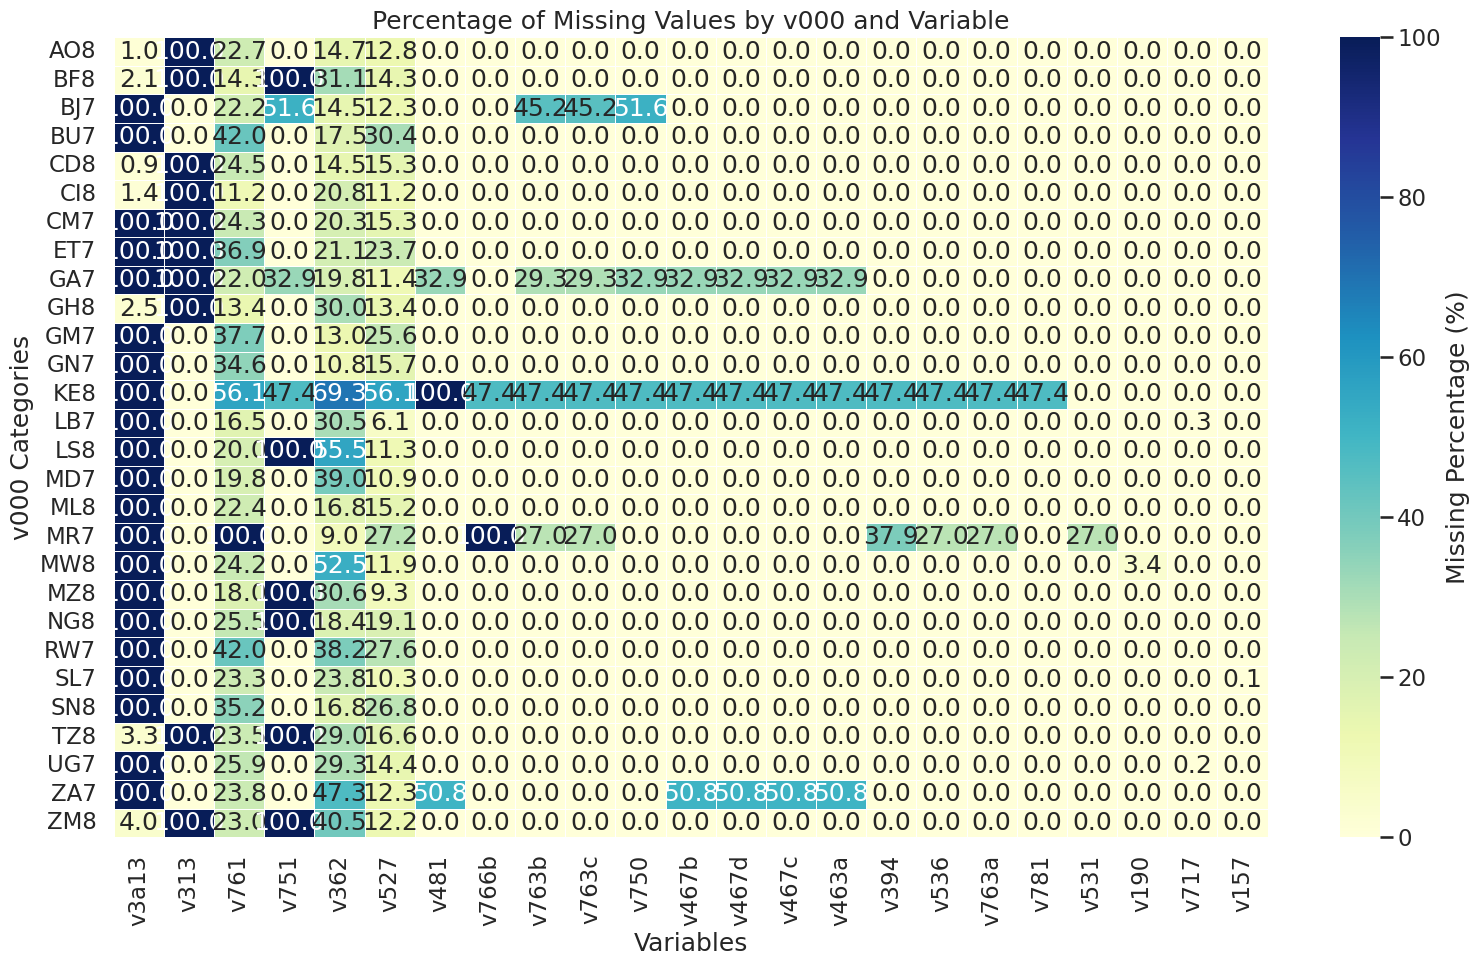

In [368]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Original calculation of overall missing percentage
missing_percentage = df.isnull().sum() * 100 / len(df)
missing_percentage = missing_percentage.sort_values(ascending=False)

# Filter out columns with 0% missing values
missing_percentage_filtered = missing_percentage[missing_percentage > 0]

print("Overall Percentage of Missing Values per Column (filtered to > 0% missing):")
print(missing_percentage_filtered)
print("\n" + "="*70 + "\n")

print("Visualizing Percentage of Missing Values by 'v000' and Variable using a Heatmap:")

if not missing_percentage_filtered.empty:
    # Calculate missing percentages for each column within each v000 group
    # The result will be a DataFrame with 'v000' as index and variable names as columns
    missing_by_v000_series = df.groupby('v000')[missing_percentage_filtered.index].apply(
        lambda x: (x.isnull().sum() * 100 / len(x))
    )

    # 'missing_by_v000_series' is already in the correct DataFrame format for the heatmap.
    # No unstacking is needed. If it were a Series with MultiIndex (v000, variable),
    # then .unstack() would be appropriate to convert it to a DataFrame.
    missing_by_v000_pivot = missing_by_v000_series

    # Fill NaN values with 0 for a cleaner heatmap. These NaNs would occur if a specific v000 group
    # did not contain a particular column from 'missing_percentage_filtered.index', or if a column
    # had 0 missing values for a particular v000 group, resulting in a NaN after the division.
    missing_by_v000_pivot = missing_by_v000_pivot.fillna(0)

    # Ensure the columns are sorted by the overall missing percentage for better readability
    # Filter to only include columns that are actually in missing_by_v000_pivot
    sorted_columns = [col for col in missing_percentage_filtered.index if col in missing_by_v000_pivot.columns]
    missing_by_v000_pivot = missing_by_v000_pivot[sorted_columns]

    plt.figure(figsize=(16, 10))
    sns.heatmap(missing_by_v000_pivot, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5, cbar_kws={'label': 'Missing Percentage (%)'})
    plt.title('Percentage of Missing Values by v000 and Variable')
    plt.xlabel('Variables')
    plt.ylabel('v000 Categories')
    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("No columns with missing values to visualize.")

Variables with > 30% missing values to be removed: ['v362', 'v3a13', 'v313']
New DataFrame shape after dropping columns: (388172, 39)


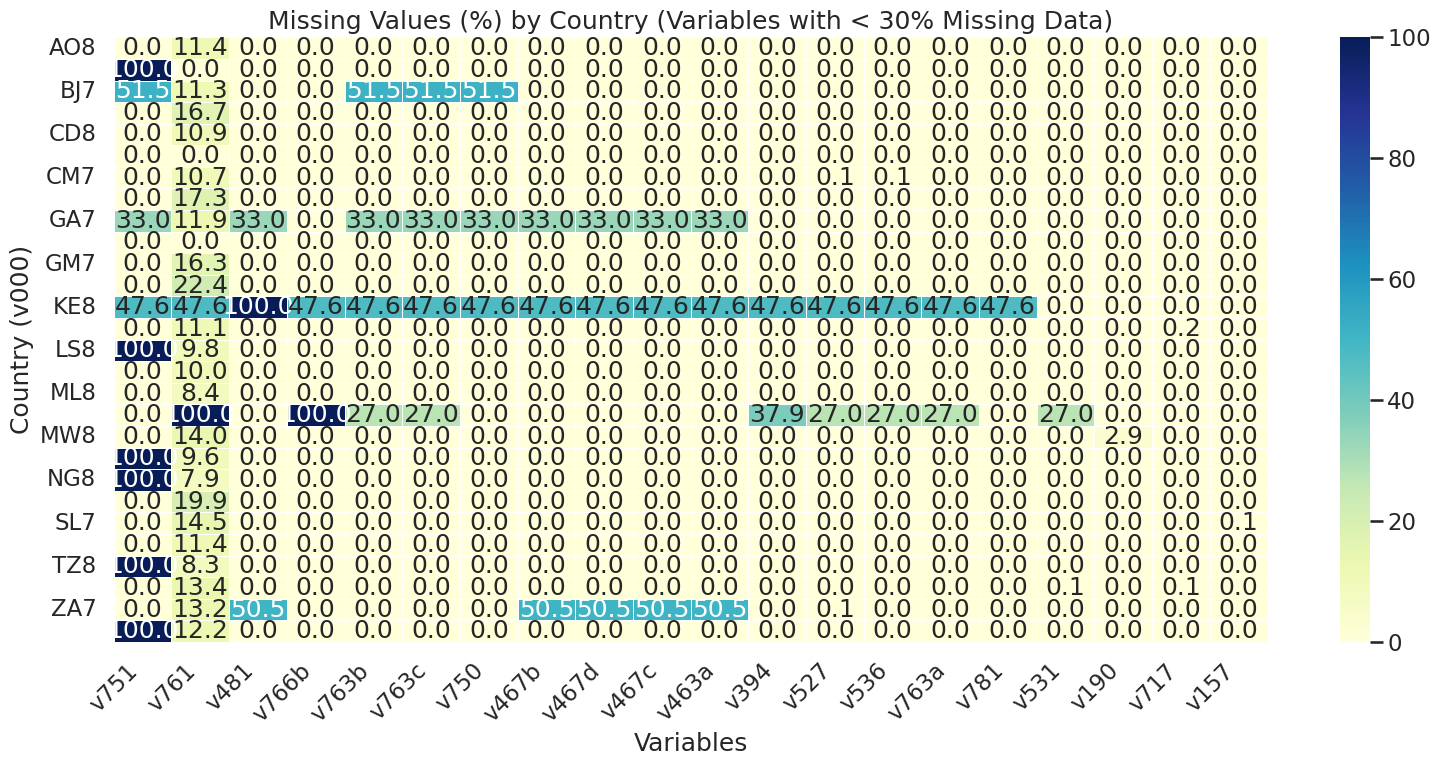

In [369]:
# 1. Identify variables with > 30% missing values in the filtered dataframe
missing_pct_filtered = df_filtered.isnull().sum() * 100 / len(df_filtered)
vars_to_drop = missing_pct_filtered[missing_pct_filtered > 30].index.tolist()

print(f"Variables with > 30% missing values to be removed: {vars_to_drop}")

# 2. Drop these variables
df_cleaned = df_filtered.drop(columns=vars_to_drop)
print(f"New DataFrame shape after dropping columns: {df_cleaned.shape}")

# 3. Recalculate missing percentages for visualization (> 0% but <= 30%)
remaining_missing = df_cleaned.isnull().sum() * 100 / len(df_cleaned)
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

# 4. Visualize again via Heatmap
if not remaining_missing.empty:
    missing_by_v000_new = df_cleaned.groupby('v000')[remaining_missing.index].apply(
        lambda x: (x.isnull().sum() * 100 / len(x))
    ).fillna(0)

    plt.figure(figsize=(16, 8))
    sns.heatmap(missing_by_v000_new, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5)
    plt.title('Missing Values (%) by Country (Variables with < 30% Missing Data)')
    plt.xlabel('Variables')
    plt.ylabel('Country (v000)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No variables with missing values remaining after the threshold cut.")

In [370]:
# Drop the specific variable v751 from the cleaned dataframe
df_cleaned = df_cleaned.drop(columns=['v751'])

print(f"Dropped column: v751")
print(f"New DataFrame shape: {df_cleaned.shape}")

# Re-check remaining missing variables if you want to visualize later
remaining_cols = [col for col in df_cleaned.columns if df_cleaned[col].isnull().any()]
print(f"Remaining columns with missing values: {remaining_cols}")

Dropped column: v751
New DataFrame shape: (388172, 38)
Remaining columns with missing values: ['v157', 'v190', 'v394', 'v463a', 'v467b', 'v467c', 'v467d', 'v481', 'v527', 'v531', 'v536', 'v717', 'v750', 'v761', 'v763a', 'v763b', 'v763c', 'v766b', 'v781']


Descriptive Statistics for v012:
count    388172.00000
mean         30.59942
std           9.05731
min          15.00000
25%          23.00000
50%          30.00000
75%          38.00000
max          49.00000
Name: v012, dtype: float64

Unique values (top 10):
v012
25    17311
30    16883
20    16541
23    15211
28    14881
24    14495
22    14487
35    14219
27    13971
26    13758
Name: count, dtype: int64


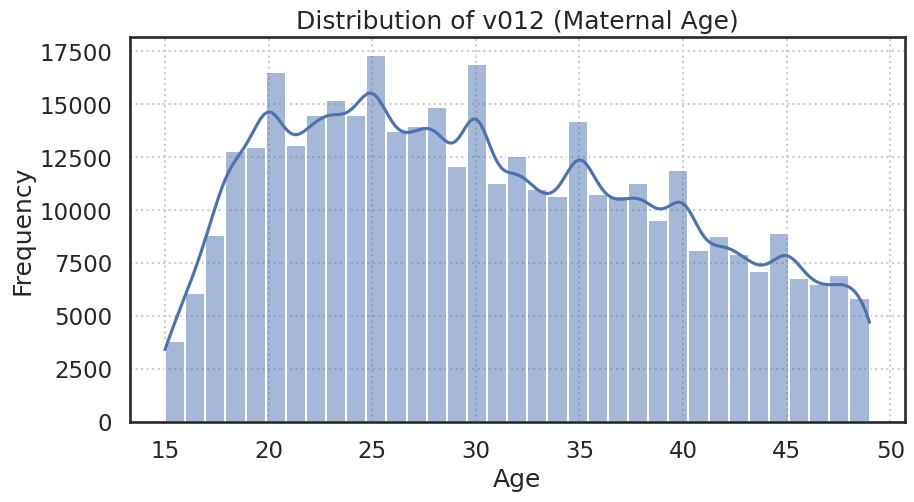

In [371]:
# Summarize the v012 (Maternal age) column
print("Descriptive Statistics for v012:")
print(df_cleaned['v012'].describe())

print("\nUnique values (top 10):")
print(df_cleaned['v012'].value_counts().head(10))

# Quick visual check of the distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df_cleaned['v012'], bins=35, kde=True)
plt.title('Distribution of v012 (Maternal Age)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [372]:
df_cleaned.columns

Index(['caseid', 'v000', 'v001', 'v005', 'v007', 'v012', 'v021', 'v025',
       'v106', 'v151', 'v152', 'v157', 'v158', 'v159', 'v169a', 'v171a',
       'v190', 'v213', 'v228', 'v312', 'v394', 'v463a', 'v467b', 'v467c',
       'v467d', 'v481', 'v501', 'v527', 'v531', 'v536', 'v717', 'v750', 'v761',
       'v763a', 'v763b', 'v763c', 'v766b', 'v781'],
      dtype='object')

In [373]:
# Value counts for v763a, v763b, and v763c
for col in ['v763a', 'v763b', 'v763c']:
    print(f"--- Value Counts for {col} ---")
    print(df_cleaned[col].value_counts(dropna=False))
    print("\n")

--- Value Counts for v763a ---
v763a
no            344603
yes            25945
NaN            17032
don't know       592
Name: count, dtype: int64


--- Value Counts for v763b ---
v763b
no            330949
yes            28323
NaN            27012
don't know      1888
Name: count, dtype: int64


--- Value Counts for v763c ---
v763c
no            306752
yes            52547
NaN            27012
don't know      1861
Name: count, dtype: int64




## Defining Outcome variable

In [374]:
# Define the condition: any of the three columns is 'yes'
# We use .fillna('no') to treat NaNs as 'No' since the user requested 'other as No'
condition = (
    (df_cleaned['v763a'] == 'yes') |
    (df_cleaned['v763b'] == 'yes') |
    (df_cleaned['v763c'] == 'yes')
)

# Create the new variable SR_STI with binary scale
df_cleaned['SR_STI'] = 0  # Default to 0 (No)
df_cleaned.loc[condition, 'SR_STI'] = 1  # Set to 1 (Yes) where condition is true

# Display the counts for the new variable
print("Value counts for the newly created 'SR_STI' variable (binary):")
print(df_cleaned['SR_STI'].value_counts())

# Cross-tab check to verify logic (optional)
print("\nCross-tabulation with v763a to verify logic:")
display(pd.crosstab(df_cleaned['v763a'], df_cleaned['SR_STI'], dropna=False))

Value counts for the newly created 'SR_STI' variable (binary):
SR_STI
0    318841
1     69331
Name: count, dtype: int64

Cross-tabulation with v763a to verify logic:


SR_STI,0,1
v763a,,
don't know,352,240
no,301457,43146
yes,0,25945
NaN,17032,0


In [375]:
# Create a new categorical variable for Women's Age
bins = [14, 24, 34, 49]
labels = ['15-24', '25-34', '35-49']

df_cleaned['Women_Age'] = pd.cut(df_cleaned['v012'], bins=bins, labels=labels)

# Display the value counts for the new variable
print("Value counts for the new 'Women_Age' variable:")
print(df_cleaned['Women_Age'].value_counts().sort_index())

# Verify the mapping with a cross-tabulation
print("\nVerification of age grouping (min/max per category):")
print(df_cleaned.groupby('Women_Age')['v012'].agg(['min', 'max']))

Value counts for the new 'Women_Age' variable:
Women_Age
15-24    118372
25-34    134430
35-49    135370
Name: count, dtype: int64

Verification of age grouping (min/max per category):
           min  max
Women_Age          
15-24       15   24
25-34       25   34
35-49       35   49


/tmp/ipykernel_3206/1824932240.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_cleaned.groupby('Women_Age')['v012'].agg(['min', 'max']))


In [376]:
# Create new variable Residence from v025
df_cleaned['Residence'] = df_cleaned['v025']

# Display value counts for the new Residence variable
print("Value counts for 'Residence':")
print(df_cleaned['Residence'].value_counts(dropna=False))

# Confirm the first few rows
display(df_cleaned[['v025', 'Residence']].head())

Value counts for 'Residence':
Residence
rural    237470
urban    150702
Name: count, dtype: int64


,v025,Residence
0,urban,urban
1,urban,urban
2,urban,urban
3,urban,urban
4,urban,urban


In [377]:
# Define the mapping for recategorization
education_mapping = {
    'no education': 'No education',
    'primary': 'Primary Education',
    'secondary': 'secondary and above',
    'higher': 'secondary and above'
}

# Apply the mapping to create the simplified categories
df_cleaned['Womens_educational_status'] = df_cleaned['v106'].replace(education_mapping)

# Display the updated value counts
print("Updated Value counts for 'Womens_educational_status':")
print(df_cleaned['Womens_educational_status'].value_counts(dropna=False))

# Verification preview
display(df_cleaned[['v106', 'Womens_educational_status']].head(10))

Updated Value counts for 'Womens_educational_status':
Womens_educational_status
secondary and above    146813
No education           122938
Primary Education      118421
Name: count, dtype: int64


,v106,Womens_educational_status
0,secondary,secondary and above
1,primary,Primary Education
2,no education,No education
3,no education,No education
4,no education,No education
6,secondary,secondary and above
7,no education,No education
8,no education,No education
9,primary,Primary Education
10,secondary,secondary and above


In [378]:
# First, check existing categories in v501 to ensure full coverage
print("Original categories in v501:")
print(df_cleaned['v501'].value_counts(dropna=False))

# Define the mapping for recategorization
marital_mapping = {
    'never in union': 'Never in union',
    'married': 'Currentily in union',
    'living with partner': 'Currentily in union',
    'widowed': 'Formly in Union',
    'divorced': 'Formly in Union',
    'no longer living together/separated': 'Formly in Union',
    '6': 'Never in union'  # Added mapping for numerical '6'
}

# Create the new Marital_Status variable
df_cleaned['Marital_Status'] = df_cleaned['v501'].replace(marital_mapping)

# Display updated counts
print("\nUpdated Value counts for 'Marital_Status':")
print(df_cleaned['Marital_Status'].value_counts(dropna=False))

# Verification preview
display(df_cleaned[['v501', 'Marital_Status']].head(10))

Original categories in v501:
v501
married                                220754
never in union                          67001
living with partner                     58958
no longer living together/separated     19673
divorced                                11091
widowed                                 10660
6                                          35
Name: count, dtype: int64

Updated Value counts for 'Marital_Status':
Marital_Status
Currentily in union    279712
Never in union          67036
Formly in Union         41424
Name: count, dtype: int64


,v501,Marital_Status
0,living with partner,Currentily in union
1,living with partner,Currentily in union
2,living with partner,Currentily in union
3,living with partner,Currentily in union
4,no longer living together/separated,Formly in Union
6,living with partner,Currentily in union
7,living with partner,Currentily in union
8,living with partner,Currentily in union
9,no longer living together/separated,Formly in Union
10,no longer living together/separated,Formly in Union


In [379]:
# Define a comprehensive mapping based on the categories provided
work_mapping = {
    'not working': 'No',
    'agricultural - self employed': 'Yes',
    'sales': 'Yes',
    'services': 'Yes',
    'professional/technical/managerial': 'Yes',
    'agricultural - employee': 'Yes',
    'unskilled manual': 'Yes',
    'skilled manual': 'Yes',
    'household and domestic': 'Yes',
    'clerical': 'Yes',
    'don\'t know/other': 'No',  # Assuming other/don't know is not actively working
    '96': 'No',
    '.a': 'No',
    '10': 'No'
}

# Create the new variable Women_currently_Working
# We use map or replace. For categorical logic, we map specifically and fill others as 'No'
df_cleaned['Women_currently_Working'] = df_cleaned['v717'].replace(work_mapping)

# Ensure NaN values are also treated as 'No' or kept as NaN
df_cleaned['Women_currently_Working'] = df_cleaned['Women_currently_Working'].fillna('No')

# Display updated counts for the new variable
print("Value counts for 'Women_currently_Working':")
print(df_cleaned['Women_currently_Working'].value_counts(dropna=False))

# Verification preview of original vs new
display(df_cleaned[['v717', 'Women_currently_Working']].value_counts().reset_index())

Value counts for 'Women_currently_Working':
Women_currently_Working
Yes    247705
No     140467
Name: count, dtype: int64


,v717,Women_currently_Working,count
0,not working,No,134535
1,agricultural - self employed,Yes,74316
2,sales,Yes,61255
3,services,Yes,28580
4,professional/technical/managerial,Yes,20161
5,agricultural - employee,Yes,19797
6,unskilled manual,Yes,19792
7,skilled manual,Yes,14274
8,household and domestic,Yes,6004
9,96,No,3978


In [380]:
df_cleaned.head()

,caseid,v000,v001,v005,v007,v012,v021,v025,v106,v151,v152,v157,v158,v159,v169a,v171a,v190,v213,v228,v312,v394,v463a,v467b,v467c,v467d,v481,v501,v527,v531,v536,v717,v750,v761,v763a,v763b,v763c,v766b,v781,SR_STI,Women_Age,Residence,Womens_educational_status,Marital_Status,Women_currently_Working
0,1 1 01,AO8,1,771031,2023,21,1,urban,secondary,female,22,not at all,not at all,not at all,no,never,poorer,no or unsure,no,not using,no,no,not a big problem,not a big problem,not a big problem,no,living with partner,406,inconsistent,not active in last 4 weeks - postpartum abstin...,not working,no,NaN,no,no,no,0,no,0,15-24,urban,secondary and above,Currentily in union,No
1,1 2 02,AO8,1,771031,2023,20,1,urban,primary,male,24,not at all,not at all,not at all,no,never,poorer,no or unsure,no,not using,no,no,not a big problem,not a big problem,not a big problem,no,living with partner,302,18,not active in last 4 weeks - postpartum abstin...,not working,no,no,no,no,no,1,no,0,15-24,urban,Primary Education,Currentily in union,No
2,1 3 02,AO8,1,771031,2023,21,1,urban,no education,male,27,not at all,not at all,not at all,no,never,poorer,no or unsure,no,not using,yes,no,not a big problem,big problem,not a big problem,no,living with partner,weeks: 1,15,active in last 4 weeks,not working,yes,no,no,no,no,1,yes,0,15-24,urban,No education,Currentily in union,No
3,1 4 02,AO8,1,771031,2023,19,1,urban,no education,male,22,not at all,not at all,not at all,no,never,poorer,no or unsure,no,not using,yes,no,not a big problem,big problem,not a big problem,no,living with partner,days: 1,11,active in last 4 weeks,not working,no,no,no,no,no,1,no,0,15-24,urban,No education,Currentily in union,No
4,1 7 01,AO8,1,771031,2023,32,1,urban,no education,female,36,not at all,not at all,not at all,no,never,poorest,no or unsure,no,not using,no,no,not a big problem,not a big problem,not a big problem,no,no longer living together/separated,days: 1,15,active in last 4 weeks,not working,no,no,no,no,no,1,no,0,25-34,urban,No education,Formly in Union,No


In [381]:
import numpy as np

# 1. Convert 'v531' to numeric, treating 'inconsistent' and other non-numeric strings as NaN
df_cleaned['v531_numeric'] = pd.to_numeric(df_cleaned['v531'], errors='coerce')

# 2. Impute NaNs with the mean of the column
v531_mean = df_cleaned['v531_numeric'].mean()
df_cleaned['v531_numeric'] = df_cleaned['v531_numeric'].fillna(v531_mean)

# 3. Categorize into <18 and >= 18
# We use bins [0, 18, infinity) where the first bin is [0, 18) and second is [18, inf)
df_cleaned['Age_at_first_sex'] = pd.cut(
    df_cleaned['v531_numeric'],
    bins=[0, 18, np.inf],
    labels=['<18', '>= 18'],
    right=False
)

# Display results
print(f"Mean value used for imputation: {v531_mean:.2f}")
print("\nValue counts for the new category:")
print(df_cleaned['Age_at_first_sex'].value_counts(dropna=False))

# Verify logic with a quick check
display(df_cleaned[['v531', 'v531_numeric', 'Age_at_first_sex']].head(10))

Mean value used for imputation: 16.78

Value counts for the new category:
Age_at_first_sex
<18      259924
>= 18    128248
Name: count, dtype: int64


,v531,v531_numeric,Age_at_first_sex
0,inconsistent,16.780747,<18
1,18,18.000000,>= 18
2,15,15.000000,<18
3,11,11.000000,<18
4,15,15.000000,<18
6,inconsistent,16.780747,<18
7,16,16.000000,<18
8,13,13.000000,<18
9,inconsistent,16.780747,<18
10,18,18.000000,>= 18


In [382]:
# 1. Ensure v527 and v766b are numeric for range comparison
df_cleaned['v527_num'] = pd.to_numeric(df_cleaned['v527'], errors='coerce')
df_cleaned['v766b_num'] = pd.to_numeric(df_cleaned['v766b'], errors='coerce')

# 2. Define the conditions for filtering (as per previous step)
cond_v527 = ((df_cleaned['v527_num'] >= 100) & (df_cleaned['v527_num'] <= 251)) | \
            ((df_cleaned['v527_num'] >= 300) & (df_cleaned['v527_num'] <= 311))
cond_v766b = (df_cleaned['v766b_num'] >= 2) & (df_cleaned['v766b_num'] <= 99)
mask = cond_v527 & cond_v766b

# 3. Create the numeric variable
df_cleaned['number_of_sexual_partnerin_12month_num'] = np.nan
df_cleaned.loc[mask, 'number_of_sexual_partnerin_12month_num'] = df_cleaned.loc[mask, 'v766b_num']

# 4. Categorize the partners (0, 1, >=2)
def categorize_partners(x):
    if pd.isna(x): return np.nan
    if x == 0: return '0'
    if x == 1: return '1'
    if x >= 2: return '>=2'
    return str(x)

df_cleaned['number_of_sexual_partnerin_12month'] = df_cleaned['v766b_num'].apply(categorize_partners)

# 5. Mode Imputation for all remaining missing values
missing_cols = df_cleaned.columns[df_cleaned.isnull().any()].tolist()
for col in missing_cols:
    # Fill missing values with the first mode found
    col_mode = df_cleaned[col].mode()
    if not col_mode.empty:
        df_cleaned[col] = df_cleaned[col].fillna(col_mode[0])

# Display results
print("Mode imputation complete. Remaining missing values:", df_cleaned.isnull().sum().sum())
print("\nValue counts for 'number_of_sexual_partnerin_12month':")
print(df_cleaned['number_of_sexual_partnerin_12month'].value_counts(dropna=False))

# Preview
display(df_cleaned[['v766b', 'number_of_sexual_partnerin_12month']].head())

Mode imputation complete. Remaining missing values: 0

Value counts for 'number_of_sexual_partnerin_12month':
number_of_sexual_partnerin_12month
1      334430
0       43426
>=2     10316
Name: count, dtype: int64


,v766b,number_of_sexual_partnerin_12month
0,0,0
1,1,1
2,1,1
3,1,1
4,1,1


In [383]:
# Drop the temporary numeric columns as requested
cols_to_drop = ['v527_num', 'v766b_num', 'number_of_sexual_partnerin_12month_num', 'v531_numeric']
df_cleaned = df_cleaned.drop(columns=cols_to_drop, errors='ignore')

# Display the updated columns and the first few rows
print(f"Dropped columns: {cols_to_drop}")
print(f"New DataFrame shape: {df_cleaned.shape}")
display(df_cleaned.head())

Dropped columns: ['v527_num', 'v766b_num', 'number_of_sexual_partnerin_12month_num', 'v531_numeric']
New DataFrame shape: (388172, 46)


,caseid,v000,v001,v005,v007,v012,v021,v025,v106,v151,v152,v157,v158,v159,v169a,v171a,v190,v213,v228,v312,v394,v463a,v467b,v467c,v467d,v481,v501,v527,v531,v536,v717,v750,v761,v763a,v763b,v763c,v766b,v781,SR_STI,Women_Age,Residence,Womens_educational_status,Marital_Status,Women_currently_Working,Age_at_first_sex,number_of_sexual_partnerin_12month
0,1 1 01,AO8,1,771031,2023,21,1,urban,secondary,female,22,not at all,not at all,not at all,no,never,poorer,no or unsure,no,not using,no,no,not a big problem,not a big problem,not a big problem,no,living with partner,406,inconsistent,not active in last 4 weeks - postpartum abstin...,not working,no,no,no,no,no,0,no,0,15-24,urban,secondary and above,Currentily in union,No,<18,0
1,1 2 02,AO8,1,771031,2023,20,1,urban,primary,male,24,not at all,not at all,not at all,no,never,poorer,no or unsure,no,not using,no,no,not a big problem,not a big problem,not a big problem,no,living with partner,302,18,not active in last 4 weeks - postpartum abstin...,not working,no,no,no,no,no,1,no,0,15-24,urban,Primary Education,Currentily in union,No,>= 18,1
2,1 3 02,AO8,1,771031,2023,21,1,urban,no education,male,27,not at all,not at all,not at all,no,never,poorer,no or unsure,no,not using,yes,no,not a big problem,big problem,not a big problem,no,living with partner,weeks: 1,15,active in last 4 weeks,not working,yes,no,no,no,no,1,yes,0,15-24,urban,No education,Currentily in union,No,<18,1
3,1 4 02,AO8,1,771031,2023,19,1,urban,no education,male,22,not at all,not at all,not at all,no,never,poorer,no or unsure,no,not using,yes,no,not a big problem,big problem,not a big problem,no,living with partner,days: 1,11,active in last 4 weeks,not working,no,no,no,no,no,1,no,0,15-24,urban,No education,Currentily in union,No,<18,1
4,1 7 01,AO8,1,771031,2023,32,1,urban,no education,female,36,not at all,not at all,not at all,no,never,poorest,no or unsure,no,not using,no,no,not a big problem,not a big problem,not a big problem,no,no longer living together/separated,days: 1,15,active in last 4 weeks,not working,no,no,no,no,no,1,no,0,25-34,urban,No education,Formly in Union,No,<18,1


In [384]:
# Create the new variable 'Condom_use_in_last_sex' from the original column v761
df_cleaned['Condom_use_in_last_sex'] = df_cleaned['v761']

# Display the value counts for the new variable
print("Value counts for 'Condom_use_in_last_sex':")
print(df_cleaned['Condom_use_in_last_sex'].value_counts(dropna=False))

# Verification preview - Fixed the missing quote and column list
display(df_cleaned[['v761', 'Condom_use_in_last_sex']].head())

Value counts for 'Condom_use_in_last_sex':
Condom_use_in_last_sex
no     362168
yes     26004
Name: count, dtype: int64


,v761,Condom_use_in_last_sex
0,no,no
1,no,no
2,no,no
3,no,no
4,no,no


In [385]:
# Define the mapping for wealth index recategorization
wealth_mapping = {
    'poorest': 'Poor',
    'poorer': 'Poor',
    'middle': 'Middle',
    'richer': 'Rich',
    'richest': 'Rich'
}

# Create the new variable 'Wealth_index'
df_cleaned['Wealth_index'] = df_cleaned['v190'].replace(wealth_mapping)

# Display the value counts for the original and new variable for verification
print("Original categories in v190:")
print(df_cleaned['v190'].value_counts(dropna=False))

print("\nNew Wealth_index categories:")
print(df_cleaned['Wealth_index'].value_counts(dropna=False))

# Preview the first few rows
display(df_cleaned[['v190', 'Wealth_index']].head())

Original categories in v190:
v190
poorest    82753
middle     77777
richest    76547
richer     76158
poorer     74937
Name: count, dtype: int64

New Wealth_index categories:
Wealth_index
Poor      157690
Rich      152705
Middle     77777
Name: count, dtype: int64


,v190,Wealth_index
0,poorer,Poor
1,poorer,Poor
2,poorer,Poor
3,poorer,Poor
4,poorest,Poor


In [386]:
# Create the new variable 'Health_Insurance_coverage' from v481
df_cleaned['Health_Insurance_coverage'] = df_cleaned['v481']

# Display the value counts for the new variable
print("Value counts for 'Health_Insurance_coverage':")
print(df_cleaned['Health_Insurance_coverage'].value_counts(dropna=False))

# Preview the first few rows for verification
display(df_cleaned[['v481', 'Health_Insurance_coverage']].head())

Value counts for 'Health_Insurance_coverage':
Health_Insurance_coverage
no     348387
yes     39785
Name: count, dtype: int64


,v481,Health_Insurance_coverage
0,no,no
1,no,no
2,no,no
3,no,no
4,no,no


In [387]:
# 1. Map DHS country codes (v000) to full names
country_mapping = {
    'AO8': 'Angola', 'BF8': 'Burkina Faso', 'BJ7': 'Benin', 'BU7': 'Burundi',
    'CD8': 'DR Congo', 'CI8': 'Cote de Ivoire', 'CM7': 'Cameroon',
    'ET7': 'Ethiopia', 'GA7': 'Gabon', 'GH8': 'Ghana', 'GM7': 'Gambia',
    'GN7': 'Guinea', 'KE8': 'Kenya', 'LB7': 'Liberia', 'LS8': 'Lesotho',
    'MD7': 'Madagascar', 'ML8': 'Mali', 'MR7': 'Mauritania', 'MW8': 'Malawi',
    'MZ8': 'Mozambique', 'NG8': 'Nigeria', 'RW7': 'Rwanda', 'SL7': 'Sierra Leone',
    'SN8': 'Senegal', 'TZ8': 'Tanzania', 'UG7': 'Uganda', 'ZA7': 'South Africa',
    'ZM8': 'Zambia'
}

# 2. Map countries to African Regions based on user classification
region_mapping = {
    # East Africa
    'Burundi': 'East Africa', 'Ethiopia': 'East Africa', 'Kenya': 'East Africa',
    'Madagascar': 'East Africa', 'Malawi': 'East Africa', 'Mozambique': 'East Africa',
    'Rwanda': 'East Africa', 'Tanzania': 'East Africa', 'Uganda': 'East Africa',
    'Zambia': 'East Africa',

    # West Africa
    'Benin': 'West Africa', 'Burkina Faso': 'West Africa', 'Cote de Ivoire': 'West Africa',
    'Gambia': 'West Africa', 'Ghana': 'West Africa', 'Guinea': 'West Africa',
    'Liberia': 'West Africa', 'Mali': 'West Africa', 'Mauritania': 'West Africa',
    'Nigeria': 'West Africa', 'Senegal': 'West Africa', 'Sierra Leone': 'West Africa',

    # Central Africa
    'Angola': 'Central Africa', 'Cameroon': 'Central Africa', 'DR Congo': 'Central Africa',
    'Gabon': 'Central Africa',

    # Southern Africa
    'Lesotho': 'Southern Africa', 'South Africa': 'Southern Africa'
}

# Apply country mapping
df_cleaned['Country_Name'] = df_cleaned['v000'].map(country_mapping).fillna(df_cleaned['v000'])

# Apply regional mapping
df_cleaned['Geographic_Region'] = df_cleaned['Country_Name'].map(region_mapping)

# Display value counts for the new regional categorization
print("Value counts for 'Geographic_Region':")
print(df_cleaned['Geographic_Region'].value_counts())

# Verification
display(df_cleaned[['v000', 'Country_Name', 'Geographic_Region']].head())

Value counts for 'Geographic_Region':
Geographic_Region
West Africa        168836
East Africa        150077
Central Africa      56097
Southern Africa     13162
Name: count, dtype: int64


,v000,Country_Name,Geographic_Region
0,AO8,Angola,Central Africa
1,AO8,Angola,Central Africa
2,AO8,Angola,Central Africa
3,AO8,Angola,Central Africa
4,AO8,Angola,Central Africa


In [388]:
# Rename v169a to Owns_mobile
df_cleaned = df_cleaned.rename(columns={'v169a': 'Owns_mobile'})

# Display value counts for the renamed variable
print("Value counts for 'Owns_mobile':")
print(df_cleaned['Owns_mobile'].value_counts(dropna=False))

# Display first few rows to confirm
display(df_cleaned[['Owns_mobile']].head())

Value counts for 'Owns_mobile':
Owns_mobile
yes    233036
no     155136
Name: count, dtype: int64


,Owns_mobile
0,no
1,no
2,no
3,no
4,no


In [389]:
# Define categories for 'at least once a week' or 'almost every day'
# Based on typical DHS coding:
# 0: Not at all, 1: Less than once a week, 2: At least once a week, 3: Almost every day
exposure_values = ['at least once a week', 'almost every day', 2, 3, '2', '3']

# Create the condition: all three media accessed at least once a week
media_condition = (
    df_cleaned['v157'].astype(str).str.lower().isin([str(v).lower() for v in exposure_values]) &
    df_cleaned['v158'].astype(str).str.lower().isin([str(v).lower() for v in exposure_values]) &
    df_cleaned['v159'].astype(str).str.lower().isin([str(v).lower() for v in exposure_values])
)

# Create the Mass_Media_Exposure variable
df_cleaned['Mass_Media_Exposure'] = 'No'
df_cleaned.loc[media_condition, 'Mass_Media_Exposure'] = 'Yes'

# Display value counts
print("Value counts for 'Mass_Media_Exposure':")
print(df_cleaned['Mass_Media_Exposure'].value_counts())

# Verification check
display(df_cleaned[['v157', 'v158', 'v159', 'Mass_Media_Exposure']].head(10))

Value counts for 'Mass_Media_Exposure':
Mass_Media_Exposure
No     377687
Yes     10485
Name: count, dtype: int64


,v157,v158,v159,Mass_Media_Exposure
0,not at all,not at all,not at all,No
1,not at all,not at all,not at all,No
2,not at all,not at all,not at all,No
3,not at all,not at all,not at all,No
4,not at all,not at all,not at all,No
6,not at all,not at all,not at all,No
7,not at all,not at all,not at all,No
8,not at all,not at all,not at all,No
9,not at all,not at all,not at all,No
10,not at all,not at all,not at all,No


In [390]:
# Create Ever_heard_STI from v750
# Mapping typical DHS values: 'yes' -> 'Yes', everything else (no, don't know, nan) -> 'No'
df_cleaned['Ever_heard_STI'] = df_cleaned['v750'].apply(lambda x: 'Yes' if str(x).lower() == 'yes' else 'No')

# Display value counts for verification
print("Value counts for 'Ever_heard_STI':")
print(df_cleaned['Ever_heard_STI'].value_counts())

# Compare with original v750 values
print("\nComparison with original v750 values:")
print(df_cleaned['v750'].value_counts(dropna=False))

# Preview
display(df_cleaned[['v750', 'Ever_heard_STI']].head())

Value counts for 'Ever_heard_STI':
Ever_heard_STI
Yes    337881
No      50291
Name: count, dtype: int64

Comparison with original v750 values:
v750
yes    337881
no      50291
Name: count, dtype: int64


,v750,Ever_heard_STI
0,no,No
1,no,No
2,yes,Yes
3,no,No
4,no,No


In [391]:
# Tabulate original variable v536
print("Tabulation for v536 (Recent sexual activity):")
print(df_cleaned['v536'].value_counts(dropna=False))

Tabulation for v536 (Recent sexual activity):
v536
active in last 4 weeks                                    243944
not active in last 4 weeks - not postpartum abstinence    107010
not active in last 4 weeks - postpartum abstinence         37214
.a                                                             4
Name: count, dtype: int64


In [392]:
# Refined classification for Recent_sexual_activity from v536
def categorize_sexual_activity_refined(x):
    val = str(x).lower().strip()
    if val == 'active in last 4 weeks':
        return 'Active'
    else:
        return 'Non active'

df_cleaned['Recent_sexual_activity'] = df_cleaned['v536'].apply(categorize_sexual_activity_refined)

# Display value counts to verify the new distribution
print("Value counts for 'Recent_sexual_activity':")
print(df_cleaned['Recent_sexual_activity'].value_counts())

# Detailed cross-tabulation with original v536
print("\nDetailed mapping verification:")
print(pd.crosstab(df_cleaned['v536'], df_cleaned['Recent_sexual_activity']))

# Preview
display(df_cleaned[['v536', 'Recent_sexual_activity']].head())

Value counts for 'Recent_sexual_activity':
Recent_sexual_activity
Active        243944
Non active    144228
Name: count, dtype: int64

Detailed mapping verification:
Recent_sexual_activity                              Active  Non active
v536                                                                  
.a                                                       0           4
active in last 4 weeks                              243944           0
not active in last 4 weeks - not postpartum abs...       0      107010
not active in last 4 weeks - postpartum abstinence       0       37214


,v536,Recent_sexual_activity
0,not active in last 4 weeks - postpartum abstin...,Non active
1,not active in last 4 weeks - postpartum abstin...,Non active
2,active in last 4 weeks,Active
3,active in last 4 weeks,Active
4,active in last 4 weeks,Active


In [393]:
# Create current_pregnancy_status by renaming v213
df_cleaned = df_cleaned.rename(columns={'v213': 'current_pregnancy_status'})

# Display value counts for the new variable
print("Value counts for 'current_pregnancy_status':")
print(df_cleaned['current_pregnancy_status'].value_counts(dropna=False))

# Verification preview
display(df_cleaned[['current_pregnancy_status']].head())

Value counts for 'current_pregnancy_status':
current_pregnancy_status
no or unsure    352599
yes              35573
Name: count, dtype: int64


,current_pregnancy_status
0,no or unsure
1,no or unsure
2,no or unsure
3,no or unsure
4,no or unsure


In [394]:
df_cleaned.columns

Index(['caseid', 'v000', 'v001', 'v005', 'v007', 'v012', 'v021', 'v025',
       'v106', 'v151', 'v152', 'v157', 'v158', 'v159', 'Owns_mobile', 'v171a',
       'v190', 'current_pregnancy_status', 'v228', 'v312', 'v394', 'v463a',
       'v467b', 'v467c', 'v467d', 'v481', 'v501', 'v527', 'v531', 'v536',
       'v717', 'v750', 'v761', 'v763a', 'v763b', 'v763c', 'v766b', 'v781',
       'SR_STI', 'Women_Age', 'Residence', 'Womens_educational_status',
       'Marital_Status', 'Women_currently_Working', 'Age_at_first_sex',
       'number_of_sexual_partnerin_12month', 'Condom_use_in_last_sex',
       'Wealth_index', 'Health_Insurance_coverage', 'Country_Name',
       'Geographic_Region', 'Mass_Media_Exposure', 'Ever_heard_STI',
       'Recent_sexual_activity'],
      dtype='object')

In [395]:
# 1. Rename v362 to Intention_to_use_contraceptive if it exists in df_cleaned
if 'v362' in df_cleaned.columns:
    df_cleaned = df_cleaned.rename(columns={'v362': 'Intention_to_use_contraceptive'})

# 2. Categorize: 'use later' -> Yes, all others -> No
def categorize_intention(val):
    val_str = str(val).lower().strip()
    if val_str == 'use later':
        return 'Yes'
    else:
        return 'No'

# 3. Apply the categorization if the column exists
if 'Intention_to_use_contraceptive' in df_cleaned.columns:
    df_cleaned['Intention_to_use_contraceptive'] = df_cleaned['Intention_to_use_contraceptive'].apply(categorize_intention)

    # Display updated value counts
    print("Value counts for 'Intention_to_use_contraceptive':")
    print(df_cleaned['Intention_to_use_contraceptive'].value_counts(dropna=False))

    # Verification preview
    display(df_cleaned[['Intention_to_use_contraceptive']].head())
else:
    print("Error: Column 'v362' was not found in the DataFrame.")

Error: Column 'v362' was not found in the DataFrame.


In [396]:
# Create Smoking_status by renaming v463a
df_cleaned = df_cleaned.rename(columns={'v463a': 'Smoking_status'})

# Display value counts for the new variable
print("Value counts for 'Smoking_status':")
print(df_cleaned['Smoking_status'].value_counts(dropna=False))

# Verification preview
display(df_cleaned[['Smoking_status']].head())

Value counts for 'Smoking_status':
Smoking_status
no     383621
yes      4551
Name: count, dtype: int64


,Smoking_status
0,no
1,no
2,no
3,no
4,no


In [397]:
df_cleaned.head()

,caseid,v000,v001,v005,v007,v012,v021,v025,v106,v151,v152,v157,v158,v159,Owns_mobile,v171a,v190,current_pregnancy_status,v228,v312,v394,Smoking_status,v467b,v467c,v467d,v481,v501,v527,v531,v536,v717,v750,v761,v763a,v763b,v763c,v766b,v781,SR_STI,Women_Age,Residence,Womens_educational_status,Marital_Status,Women_currently_Working,Age_at_first_sex,number_of_sexual_partnerin_12month,Condom_use_in_last_sex,Wealth_index,Health_Insurance_coverage,Country_Name,Geographic_Region,Mass_Media_Exposure,Ever_heard_STI,Recent_sexual_activity
0,1 1 01,AO8,1,771031,2023,21,1,urban,secondary,female,22,not at all,not at all,not at all,no,never,poorer,no or unsure,no,not using,no,no,not a big problem,not a big problem,not a big problem,no,living with partner,406,inconsistent,not active in last 4 weeks - postpartum abstin...,not working,no,no,no,no,no,0,no,0,15-24,urban,secondary and above,Currentily in union,No,<18,0,no,Poor,no,Angola,Central Africa,No,No,Non active
1,1 2 02,AO8,1,771031,2023,20,1,urban,primary,male,24,not at all,not at all,not at all,no,never,poorer,no or unsure,no,not using,no,no,not a big problem,not a big problem,not a big problem,no,living with partner,302,18,not active in last 4 weeks - postpartum abstin...,not working,no,no,no,no,no,1,no,0,15-24,urban,Primary Education,Currentily in union,No,>= 18,1,no,Poor,no,Angola,Central Africa,No,No,Non active
2,1 3 02,AO8,1,771031,2023,21,1,urban,no education,male,27,not at all,not at all,not at all,no,never,poorer,no or unsure,no,not using,yes,no,not a big problem,big problem,not a big problem,no,living with partner,weeks: 1,15,active in last 4 weeks,not working,yes,no,no,no,no,1,yes,0,15-24,urban,No education,Currentily in union,No,<18,1,no,Poor,no,Angola,Central Africa,No,Yes,Active
3,1 4 02,AO8,1,771031,2023,19,1,urban,no education,male,22,not at all,not at all,not at all,no,never,poorer,no or unsure,no,not using,yes,no,not a big problem,big problem,not a big problem,no,living with partner,days: 1,11,active in last 4 weeks,not working,no,no,no,no,no,1,no,0,15-24,urban,No education,Currentily in union,No,<18,1,no,Poor,no,Angola,Central Africa,No,No,Active
4,1 7 01,AO8,1,771031,2023,32,1,urban,no education,female,36,not at all,not at all,not at all,no,never,poorest,no or unsure,no,not using,no,no,not a big problem,not a big problem,not a big problem,no,no longer living together/separated,days: 1,15,active in last 4 weeks,not working,no,no,no,no,no,1,no,0,25-34,urban,No education,Formly in Union,No,<18,1,no,Poor,no,Angola,Central Africa,No,No,Active


In [398]:
# Create Ever_tested_for_HIV by renaming v781
df_cleaned = df_cleaned.rename(columns={'v781': 'Ever_tested_for_HIV'})

# Recategorize '.a' as 'yes'
df_cleaned['Ever_tested_for_HIV'] = df_cleaned['Ever_tested_for_HIV'].replace({'.a': 'yes'})

# Display value counts for the variable
print("Updated Value counts for 'Ever_tested_for_HIV':")
print(df_cleaned['Ever_tested_for_HIV'].value_counts(dropna=False))

# Verification preview
display(df_cleaned[['Ever_tested_for_HIV']].head())

Updated Value counts for 'Ever_tested_for_HIV':
Ever_tested_for_HIV
yes    229423
no     158749
Name: count, dtype: int64


,Ever_tested_for_HIV
0,no
1,no
2,yes
3,no
4,no


In [399]:
# Create Ever_terminated_pregnancy by renaming v228
df_cleaned = df_cleaned.rename(columns={'v228': 'Ever_terminated_pregnancy'})

# Display value counts for the new variable
print("Value counts for 'Ever_terminated_pregnancy':")
print(df_cleaned['Ever_terminated_pregnancy'].value_counts(dropna=False))

# Verification preview
display(df_cleaned[['Ever_terminated_pregnancy']].head())

Value counts for 'Ever_terminated_pregnancy':
Ever_terminated_pregnancy
no     325678
yes     62494
Name: count, dtype: int64


,Ever_terminated_pregnancy
0,no
1,no
2,no
3,no
4,no


In [400]:
# Create Contraceptive_use by renaming v312
df_cleaned = df_cleaned.rename(columns={'v312': 'Contraceptive_use'})

# Recategorize into Yes/No
# 'not using' -> No
# Any specific method (e.g., pill, IUD, injections, condom, etc.) -> Yes
def recategorize_contraceptive(val):
    val_str = str(val).lower().strip()
    if val_str == 'not using':
        return 'No'
    else:
        return 'Yes'

df_cleaned['Contraceptive_use'] = df_cleaned['Contraceptive_use'].apply(recategorize_contraceptive)

# Display updated value counts
print("Updated Value counts for 'Contraceptive_use':")
print(df_cleaned['Contraceptive_use'].value_counts(dropna=False))

# Verification preview
display(df_cleaned[['Contraceptive_use']].head())

Updated Value counts for 'Contraceptive_use':
Contraceptive_use
No     267891
Yes    120281
Name: count, dtype: int64


,Contraceptive_use
0,No
1,No
2,No
3,No
4,No


In [401]:
# Create Distance_to_health_facility by renaming v467d
df_cleaned = df_cleaned.rename(columns={'v467d': 'Distance_to_health_facility'})

# Display value counts for the new variable
print("Value counts for 'Distance_to_health_facility':")
print(df_cleaned['Distance_to_health_facility'].value_counts(dropna=False))

# Verification preview
display(df_cleaned[['Distance_to_health_facility']].head())

Value counts for 'Distance_to_health_facility':
Distance_to_health_facility
not a big problem    254100
big problem          134072
Name: count, dtype: int64


,Distance_to_health_facility
0,not a big problem
1,not a big problem
2,not a big problem
3,not a big problem
4,not a big problem


In [402]:
# Create Recent_health_facility_visit by renaming v394
df_cleaned = df_cleaned.rename(columns={'v394': 'Recent_health_facility_visit'})

# Display value counts for the new variable
print("Value counts for 'Recent_health_facility_visit':")
print(df_cleaned['Recent_health_facility_visit'].value_counts(dropna=False))

# Verification preview
display(df_cleaned[['Recent_health_facility_visit']].head())

Value counts for 'Recent_health_facility_visit':
Recent_health_facility_visit
yes    229731
no     158441
Name: count, dtype: int64


,Recent_health_facility_visit
0,no
1,no
2,yes
3,yes
4,no


In [403]:
df_cleaned.head()

,caseid,v000,v001,v005,v007,v012,v021,v025,v106,v151,v152,v157,v158,v159,Owns_mobile,v171a,v190,current_pregnancy_status,Ever_terminated_pregnancy,Contraceptive_use,Recent_health_facility_visit,Smoking_status,v467b,v467c,Distance_to_health_facility,v481,v501,v527,v531,v536,v717,v750,v761,v763a,v763b,v763c,v766b,Ever_tested_for_HIV,SR_STI,Women_Age,Residence,Womens_educational_status,Marital_Status,Women_currently_Working,Age_at_first_sex,number_of_sexual_partnerin_12month,Condom_use_in_last_sex,Wealth_index,Health_Insurance_coverage,Country_Name,Geographic_Region,Mass_Media_Exposure,Ever_heard_STI,Recent_sexual_activity
0,1 1 01,AO8,1,771031,2023,21,1,urban,secondary,female,22,not at all,not at all,not at all,no,never,poorer,no or unsure,no,No,no,no,not a big problem,not a big problem,not a big problem,no,living with partner,406,inconsistent,not active in last 4 weeks - postpartum abstin...,not working,no,no,no,no,no,0,no,0,15-24,urban,secondary and above,Currentily in union,No,<18,0,no,Poor,no,Angola,Central Africa,No,No,Non active
1,1 2 02,AO8,1,771031,2023,20,1,urban,primary,male,24,not at all,not at all,not at all,no,never,poorer,no or unsure,no,No,no,no,not a big problem,not a big problem,not a big problem,no,living with partner,302,18,not active in last 4 weeks - postpartum abstin...,not working,no,no,no,no,no,1,no,0,15-24,urban,Primary Education,Currentily in union,No,>= 18,1,no,Poor,no,Angola,Central Africa,No,No,Non active
2,1 3 02,AO8,1,771031,2023,21,1,urban,no education,male,27,not at all,not at all,not at all,no,never,poorer,no or unsure,no,No,yes,no,not a big problem,big problem,not a big problem,no,living with partner,weeks: 1,15,active in last 4 weeks,not working,yes,no,no,no,no,1,yes,0,15-24,urban,No education,Currentily in union,No,<18,1,no,Poor,no,Angola,Central Africa,No,Yes,Active
3,1 4 02,AO8,1,771031,2023,19,1,urban,no education,male,22,not at all,not at all,not at all,no,never,poorer,no or unsure,no,No,yes,no,not a big problem,big problem,not a big problem,no,living with partner,days: 1,11,active in last 4 weeks,not working,no,no,no,no,no,1,no,0,15-24,urban,No education,Currentily in union,No,<18,1,no,Poor,no,Angola,Central Africa,No,No,Active
4,1 7 01,AO8,1,771031,2023,32,1,urban,no education,female,36,not at all,not at all,not at all,no,never,poorest,no or unsure,no,No,no,no,not a big problem,not a big problem,not a big problem,no,no longer living together/separated,days: 1,15,active in last 4 weeks,not working,no,no,no,no,no,1,no,0,25-34,urban,No education,Formly in Union,No,<18,1,no,Poor,no,Angola,Central Africa,No,No,Active


In [404]:
# 1. Change v007 value from 2008 to 2016
df_cleaned['v007'] = df_cleaned['v007'].replace(2008, 2016)

# 2. Create Time_period by categorizing v007
# Categories: 2016-2019, 2020-2021, 2022-2025
bins = [2015, 2019, 2021, 2025]
labels = ['2016-2019', '2020-2021', '2022-2025']

df_cleaned['Time_period'] = pd.cut(df_cleaned['v007'], bins=bins, labels=labels)

# Display verification
print("Value counts for v007 after replacement:")
print(df_cleaned['v007'].value_counts().sort_index())

print("\nValue counts for new 'Time_period' variable:")
print(df_cleaned['Time_period'].value_counts().sort_index())

# Preview
display(df_cleaned[['v007', 'Time_period']].head())

Value counts for v007 after replacement:
v007
2016    42239
2017    11671
2018    27916
2019    27306
2020    31306
2021    51682
2022    61072
2023    55474
2024    79506
Name: count, dtype: int64

Value counts for new 'Time_period' variable:
Time_period
2016-2019    109132
2020-2021     82988
2022-2025    196052
Name: count, dtype: int64


,v007,Time_period
0,2023,2022-2025
1,2023,2022-2025
2,2023,2022-2025
3,2023,2022-2025
4,2023,2022-2025


In [405]:
df_cleaned.head()

,caseid,v000,v001,v005,v007,v012,v021,v025,v106,v151,v152,v157,v158,v159,Owns_mobile,v171a,v190,current_pregnancy_status,Ever_terminated_pregnancy,Contraceptive_use,Recent_health_facility_visit,Smoking_status,v467b,v467c,Distance_to_health_facility,v481,v501,v527,v531,v536,v717,v750,v761,v763a,v763b,v763c,v766b,Ever_tested_for_HIV,SR_STI,Women_Age,Residence,Womens_educational_status,Marital_Status,Women_currently_Working,Age_at_first_sex,number_of_sexual_partnerin_12month,Condom_use_in_last_sex,Wealth_index,Health_Insurance_coverage,Country_Name,Geographic_Region,Mass_Media_Exposure,Ever_heard_STI,Recent_sexual_activity,Time_period
0,1 1 01,AO8,1,771031,2023,21,1,urban,secondary,female,22,not at all,not at all,not at all,no,never,poorer,no or unsure,no,No,no,no,not a big problem,not a big problem,not a big problem,no,living with partner,406,inconsistent,not active in last 4 weeks - postpartum abstin...,not working,no,no,no,no,no,0,no,0,15-24,urban,secondary and above,Currentily in union,No,<18,0,no,Poor,no,Angola,Central Africa,No,No,Non active,2022-2025
1,1 2 02,AO8,1,771031,2023,20,1,urban,primary,male,24,not at all,not at all,not at all,no,never,poorer,no or unsure,no,No,no,no,not a big problem,not a big problem,not a big problem,no,living with partner,302,18,not active in last 4 weeks - postpartum abstin...,not working,no,no,no,no,no,1,no,0,15-24,urban,Primary Education,Currentily in union,No,>= 18,1,no,Poor,no,Angola,Central Africa,No,No,Non active,2022-2025
2,1 3 02,AO8,1,771031,2023,21,1,urban,no education,male,27,not at all,not at all,not at all,no,never,poorer,no or unsure,no,No,yes,no,not a big problem,big problem,not a big problem,no,living with partner,weeks: 1,15,active in last 4 weeks,not working,yes,no,no,no,no,1,yes,0,15-24,urban,No education,Currentily in union,No,<18,1,no,Poor,no,Angola,Central Africa,No,Yes,Active,2022-2025
3,1 4 02,AO8,1,771031,2023,19,1,urban,no education,male,22,not at all,not at all,not at all,no,never,poorer,no or unsure,no,No,yes,no,not a big problem,big problem,not a big problem,no,living with partner,days: 1,11,active in last 4 weeks,not working,no,no,no,no,no,1,no,0,15-24,urban,No education,Currentily in union,No,<18,1,no,Poor,no,Angola,Central Africa,No,No,Active,2022-2025
4,1 7 01,AO8,1,771031,2023,32,1,urban,no education,female,36,not at all,not at all,not at all,no,never,poorest,no or unsure,no,No,no,no,not a big problem,not a big problem,not a big problem,no,no longer living together/separated,days: 1,15,active in last 4 weeks,not working,no,no,no,no,no,1,no,0,25-34,urban,No education,Formly in Union,No,<18,1,no,Poor,no,Angola,Central Africa,No,No,Active,2022-2025


In [406]:
# Group the data to find the range of years per country and the total count
country_summary = df_cleaned.groupby('Country_Name').agg(
    Year_Min=('v007', 'min'),
    Year_Max=('v007', 'max'),
    Total_Survey=('v007', 'count')
).reset_index()

# Create the 'Year of Survey' string format
# Using a hyphen '-' for ranges as requested
def format_year_range(row):
    if row['Year_Min'] == row['Year_Max']:
        return str(int(row['Year_Min']))
    return f"{int(row['Year_Min'])}-{int(row['Year_Max'])}"

country_summary['Year of Survey'] = country_summary.apply(format_year_range, axis=1)

# Rename columns and select final output
final_table = country_summary[['Country_Name', 'Year of Survey', 'Total_Survey']].rename(
    columns={'Country_Name': 'Country', 'Total_Survey': 'Total Survey'}
)

# Save the final table as a CSV
final_table.to_csv('country_survey_summary.csv', index=False)
print("Table successfully saved as 'country_survey_summary.csv'")

# Display the formatted table
display(final_table)

Table successfully saved as 'country_survey_summary.csv'


,Country,Year of Survey,Total Survey
0,Angola,2023-2024,12835
1,Benin,2017-2018,13975
2,Burkina Faso,2021,15136
3,Burundi,2016-2017,12013
4,Cameroon,2018-2019,11469
5,Cote de Ivoire,2021,13214
6,DR Congo,2023-2024,23372
7,Ethiopia,2016,11962
8,Gabon,2019-2021,8421
9,Gambia,2019-2020,8824


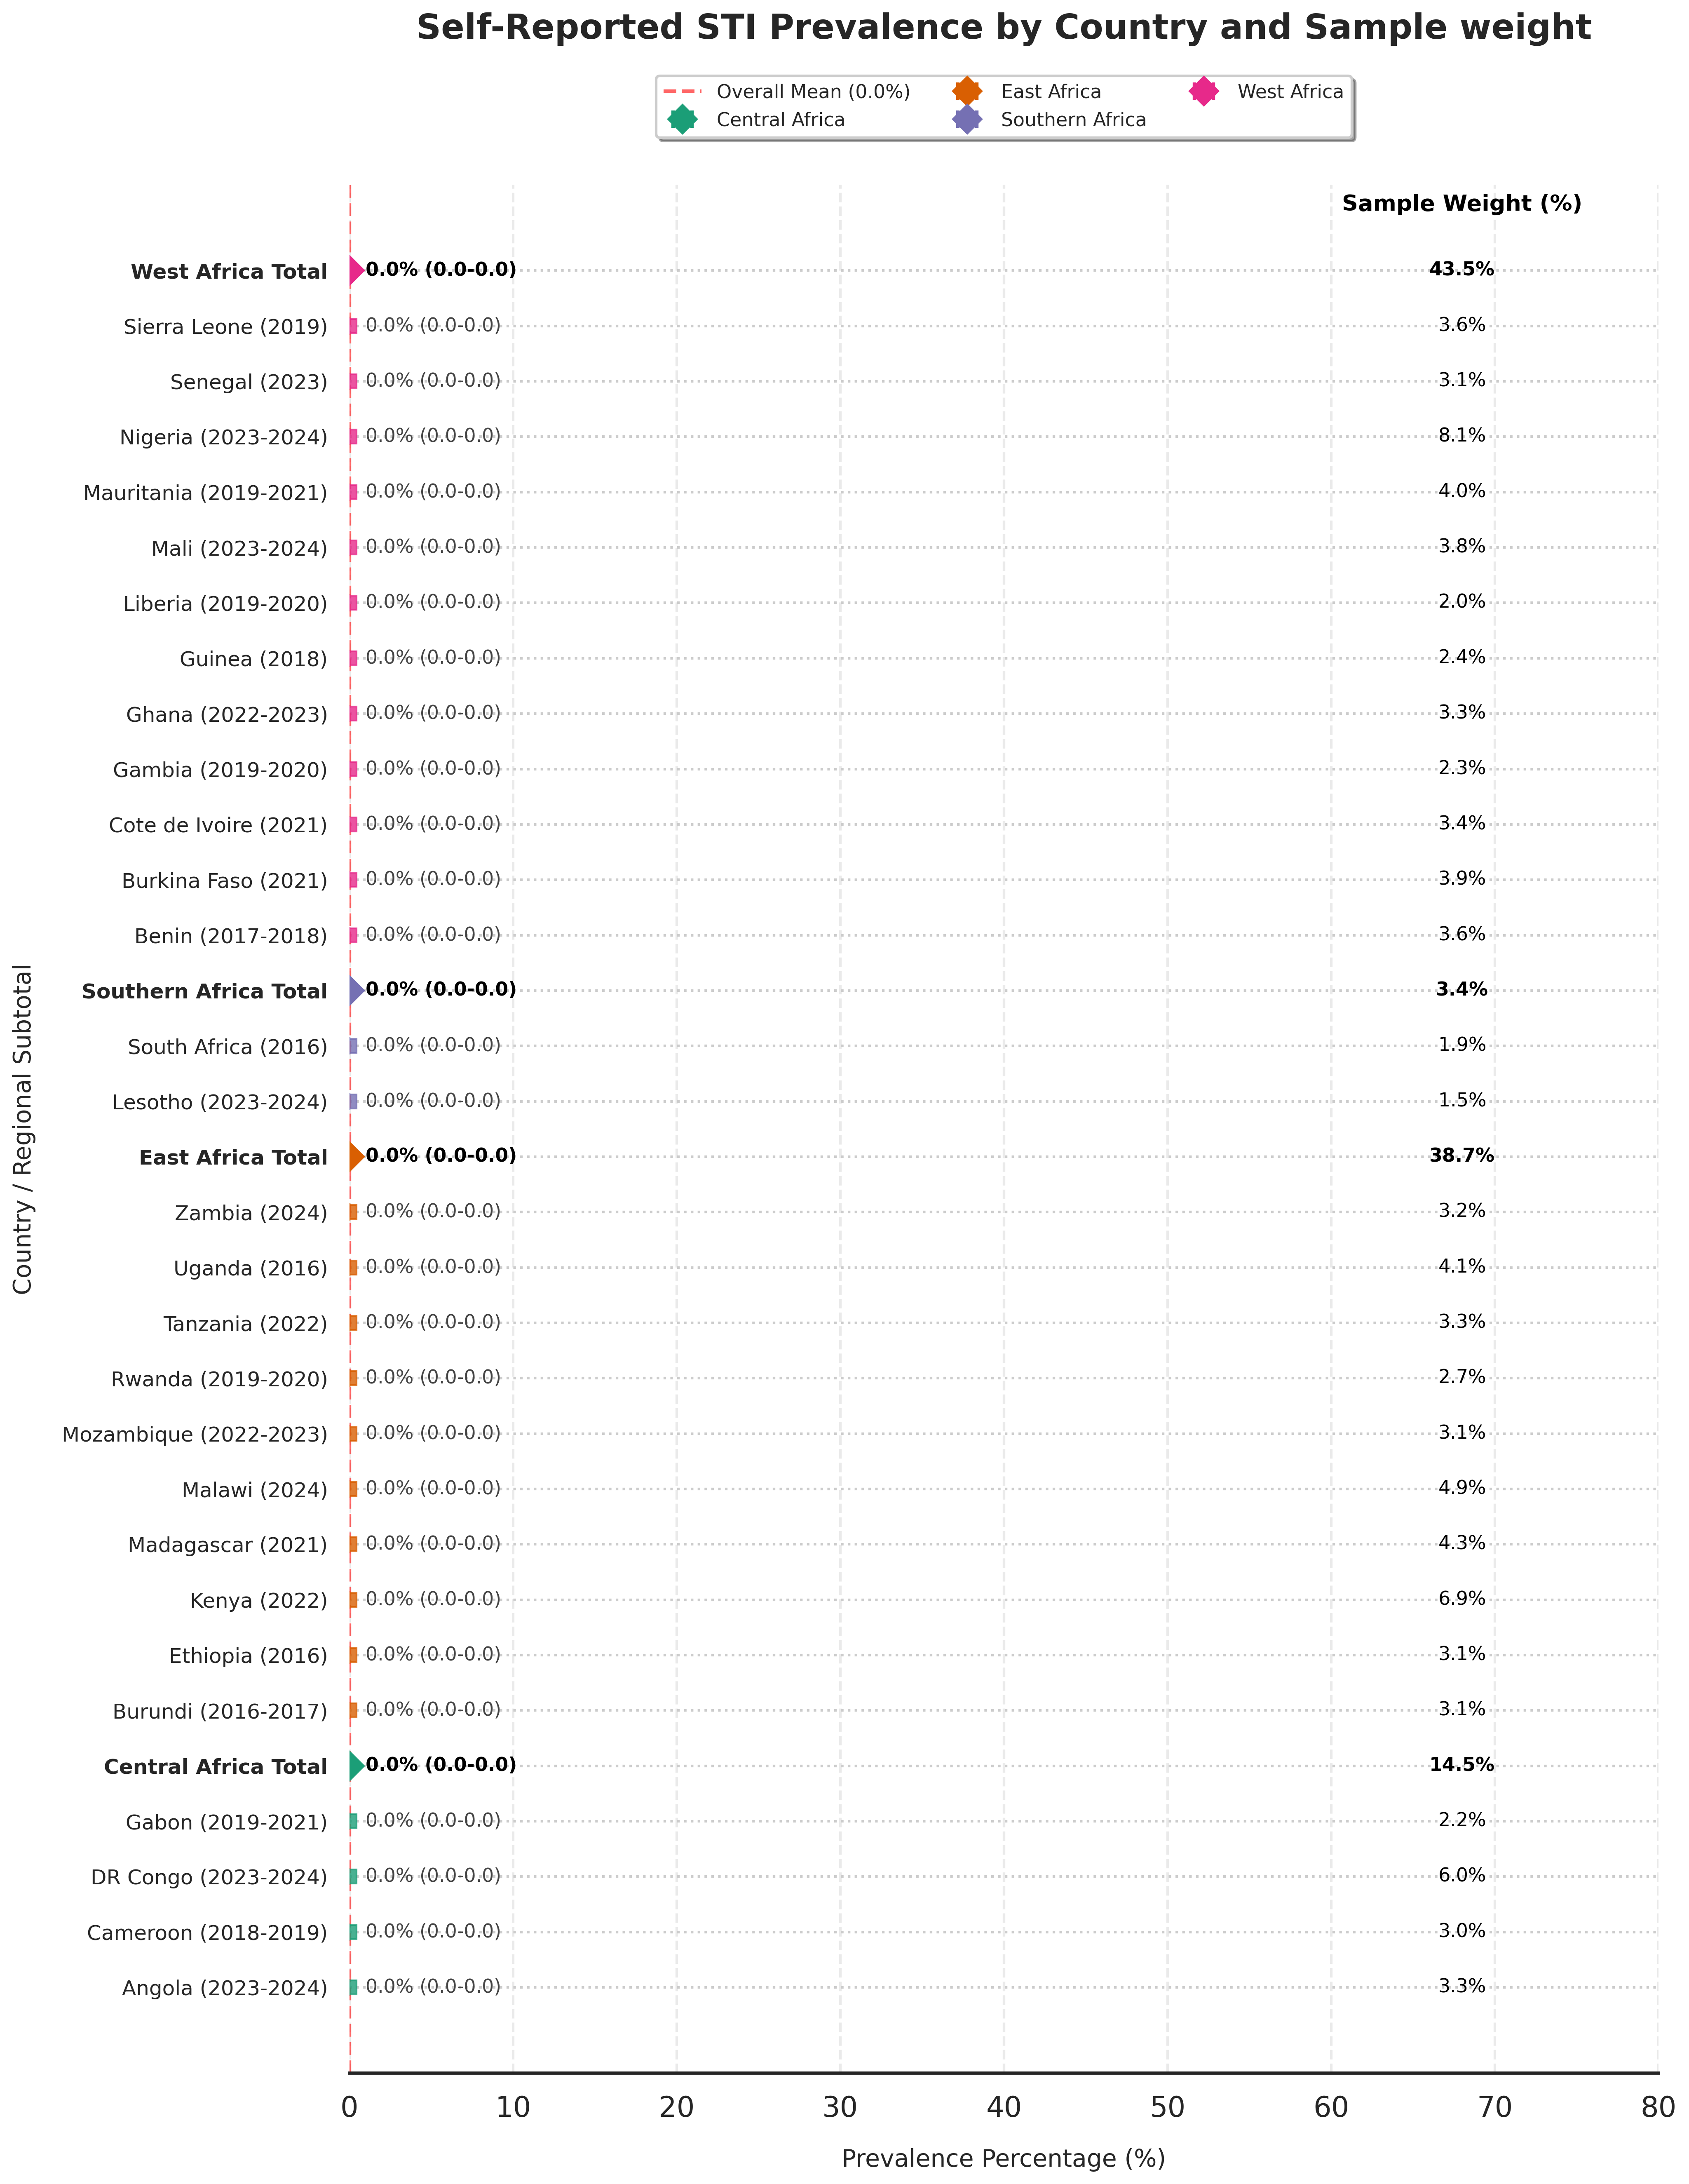

In [407]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Prepare data with 95% CI, Regions, and Weight
# Corrected column names: Country_Name, Geographic_Region, SR_STI
stats_df = df_cleaned.groupby(['Country_Name', 'Geographic_Region'])['SR_STI'].apply(lambda x: (x == 'Yes').sum()).reset_index(name='sum')
stats_df['count'] = df_cleaned.groupby(['Country_Name', 'Geographic_Region'])['SR_STI'].count().values
stats_df['Percentage'] = (stats_df['sum'] / stats_df['count']) * 100

# Merge with final_table to get the years
stats_df = pd.merge(stats_df, final_table[['Country', 'Year of Survey']], left_on='Country_Name', right_on='Country', how='left')
stats_df['country_label'] = stats_df.apply(lambda x: f"{x['Country_Name']} ({x['Year of Survey']})" if pd.notna(x['Year of Survey']) else x['Country_Name'], axis=1)

# Calculate Weight (Country N / Total N)
total_n = stats_df['count'].sum()
stats_df['Weight_pct'] = (stats_df['count'] / total_n) * 100

# Calculate Standard Error and 95% CI
stats_df['SE'] = np.sqrt((stats_df['Percentage']/100 * (1 - stats_df['Percentage']/100)) / stats_df['count']) * 100
stats_df['CI_lower'] = stats_df['Percentage'] - (1.96 * stats_df['SE'])
stats_df['CI_upper'] = stats_df['Percentage'] + (1.96 * stats_df['SE'])
stats_df['Error'] = 1.96 * stats_df['SE']
stats_df['is_subtotal'] = False

# 2. Create Subtotal Rows for each Region
regional_summaries = []
for region in stats_df['Geographic_Region'].unique():
    reg_data = stats_df[stats_df['Geographic_Region'] == region]
    r_count = reg_data['count'].sum()
    r_sum = reg_data['sum'].sum()
    r_pct = (r_sum / r_count) * 100
    r_weight = reg_data['Weight_pct'].sum()
    r_se = np.sqrt((r_pct/100 * (1 - r_pct/100)) / r_count) * 100

    summary = {
        'country_label': f"{region} Total",
        'Geographic_Region': region,
        'count': r_count,
        'sum': r_sum,
        'Percentage': r_pct,
        'Weight_pct': r_weight,
        'SE': r_se,
        'CI_lower': r_pct - (1.96 * r_se),
        'CI_upper': r_pct + (1.96 * r_se),
        'Error': 1.96 * r_se,
        'is_subtotal': True
    }
    regional_summaries.append(summary)

# 3. Combine and Sort
plot_data = pd.concat([stats_df, pd.DataFrame(regional_summaries)], ignore_index=True)
plot_data = plot_data.sort_values(['Geographic_Region', 'is_subtotal', 'Percentage'], ascending=[True, True, True])

# 4. Setup Visualization
sns.set_theme(style="whitegrid", rc={"axes.edgecolor": "0.15", "grid.linestyle": ":"})
sns.set_context("talk")
fig, ax = plt.subplots(figsize=(14, 18), dpi=300)

regions = plot_data['Geographic_Region'].unique()
colors = sns.color_palette("Dark2", len(regions))
region_color_map = dict(zip(regions, colors))

# 5. Plotting
for i, (idx, row) in enumerate(plot_data.iterrows()):
    color = region_color_map[row['Geographic_Region']]
    marker = 'D' if row['is_subtotal'] else 's'
    m_size = 11 if row['is_subtotal'] else 8
    alpha = 1.0 if row['is_subtotal'] else 0.8

    ax.errorbar(
        x=row['Percentage'],
        y=i,
        xerr=row['Error'],
        fmt=marker,
        color=color,
        markersize=m_size,
        capsize=5,
        alpha=alpha,
        markeredgewidth=2 if row['is_subtotal'] else 1,
        label=row['Geographic_Region'] if row['Geographic_Region'] not in [l.get_label() for l in ax.get_lines()] else ""
    )

    prevalence_txt = f"{row['Percentage']:.1f}% ({row['CI_lower']:.1f}-{row['CI_upper']:.1f})"
    font_weight = 'bold' if row['is_subtotal'] else 'normal'
    ax.text(row['CI_upper'] + 1, i, prevalence_txt, va='center', fontsize=11,
            color='black' if row['is_subtotal'] else '#444444', fontweight=font_weight)

    weight_txt = f"{row['Weight_pct']:.1f}%"
    ax.text(68, i, weight_txt, va='center', ha='center', fontsize=11, color='black', fontweight=font_weight)

ax.text(68, len(plot_data), 'Sample Weight (%)', va='bottom', ha='center', fontsize=13, fontweight='bold', color='black')

ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels(plot_data['country_label'], fontsize=12)
for tick in ax.get_yticklabels():
    if "Total" in tick.get_text():
        tick.set_fontweight('bold')

overall_mean = (df_cleaned['SR_STI'] == 'Yes').mean() * 100
plt.axvline(x=overall_mean, color='red', linestyle='--', alpha=0.6, linewidth=2, label=f'Overall Mean ({overall_mean:.1f}%)')

plt.title('Self-Reported STI Prevalence by Country and Sample weight', fontsize=20, pad=85, fontweight='bold')
plt.xlabel('Prevalence Percentage (%)', fontsize=14, labelpad=15)
plt.ylabel('Country / Regional Subtotal', fontsize=14, labelpad=15)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='lower center', bbox_to_anchor=(0.5, 1.02),
          ncol=3, fontsize=11, frameon=True, shadow=True)

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.xlim(0, 80)
sns.despine(left=True, bottom=False)
plt.tight_layout()

plt.savefig("STI_Forest_Plot.png", dpi=300, bbox_inches='tight')
plt.show()

In [408]:
df_cleaned.columns

Index(['caseid', 'v000', 'v001', 'v005', 'v007', 'v012', 'v021', 'v025',
       'v106', 'v151', 'v152', 'v157', 'v158', 'v159', 'Owns_mobile', 'v171a',
       'v190', 'current_pregnancy_status', 'Ever_terminated_pregnancy',
       'Contraceptive_use', 'Recent_health_facility_visit', 'Smoking_status',
       'v467b', 'v467c', 'Distance_to_health_facility', 'v481', 'v501', 'v527',
       'v531', 'v536', 'v717', 'v750', 'v761', 'v763a', 'v763b', 'v763c',
       'v766b', 'Ever_tested_for_HIV', 'SR_STI', 'Women_Age', 'Residence',
       'Womens_educational_status', 'Marital_Status',
       'Women_currently_Working', 'Age_at_first_sex',
       'number_of_sexual_partnerin_12month', 'Condom_use_in_last_sex',
       'Wealth_index', 'Health_Insurance_coverage', 'Country_Name',
       'Geographic_Region', 'Mass_Media_Exposure', 'Ever_heard_STI',
       'Recent_sexual_activity', 'Time_period'],
      dtype='object')

In [409]:
# Select the specified columns for final analysis
final_columns = [
    'Owns_mobile', 'current_pregnancy_status', 'Ever_terminated_pregnancy',
    'Contraceptive_use', 'Recent_health_facility_visit', 'Smoking_status',
    'Distance_to_health_facility', 'Ever_tested_for_HIV', 'SR_STI', 'Women_Age', 'Residence',
    'Womens_educational_status', 'Marital_Status',
    'Women_currently_Working', 'Age_at_first_sex',
    'number_of_sexual_partnerin_12month', 'Condom_use_in_last_sex',
    'Wealth_index', 'Health_Insurance_coverage', 'Country_Name',
    'Geographic_Region', 'Mass_Media_Exposure', 'Ever_heard_STI',
    'Recent_sexual_activity',  'Time_period'
]

# Create the analysis dataframe
df_analysis = df_cleaned[final_columns]

# Display the first few rows and shape
print(f"Final analysis dataset shape: {df_analysis.shape}")
display(df_analysis.head())

Final analysis dataset shape: (388172, 25)


,Owns_mobile,current_pregnancy_status,Ever_terminated_pregnancy,Contraceptive_use,Recent_health_facility_visit,Smoking_status,Distance_to_health_facility,Ever_tested_for_HIV,SR_STI,Women_Age,Residence,Womens_educational_status,Marital_Status,Women_currently_Working,Age_at_first_sex,number_of_sexual_partnerin_12month,Condom_use_in_last_sex,Wealth_index,Health_Insurance_coverage,Country_Name,Geographic_Region,Mass_Media_Exposure,Ever_heard_STI,Recent_sexual_activity,Time_period
0,no,no or unsure,no,No,no,no,not a big problem,no,0,15-24,urban,secondary and above,Currentily in union,No,<18,0,no,Poor,no,Angola,Central Africa,No,No,Non active,2022-2025
1,no,no or unsure,no,No,no,no,not a big problem,no,0,15-24,urban,Primary Education,Currentily in union,No,>= 18,1,no,Poor,no,Angola,Central Africa,No,No,Non active,2022-2025
2,no,no or unsure,no,No,yes,no,not a big problem,yes,0,15-24,urban,No education,Currentily in union,No,<18,1,no,Poor,no,Angola,Central Africa,No,Yes,Active,2022-2025
3,no,no or unsure,no,No,yes,no,not a big problem,no,0,15-24,urban,No education,Currentily in union,No,<18,1,no,Poor,no,Angola,Central Africa,No,No,Active,2022-2025
4,no,no or unsure,no,No,no,no,not a big problem,no,0,25-34,urban,No education,Formly in Union,No,<18,1,no,Poor,no,Angola,Central Africa,No,No,Active,2022-2025


In [410]:
import pandas as pd

def create_sti_summary_table_total_pct(df, variables, outcome_col='SR_STI'):
    summary_rows = []

    for var in variables:
        # Get cross tabulation
        ct = pd.crosstab(df_analysis[var], df_analysis[outcome_col])
        # Total sum of all values for this variable (Grand Total per variable)
        variable_total = ct.values.sum()

        # Add a header row for the variable
        summary_rows.append({
            'Variables': var,
            'Category': '',
            'Yes N (%)': '',
            'No N (%)': ''
        })

        # Calculate N (%) for each category where the sum of all Yes% and No% for this variable = 100%
        for category in ct.index:
            yes_n = ct.loc[category, 'Yes'] if 'Yes' in ct.columns else 0
            no_n = ct.loc[category, 'No'] if 'No' in ct.columns else 0

            if variable_total > 0:
                yes_pct = (yes_n / variable_total * 100)
                no_pct = (no_n / variable_total * 100)
            else:
                yes_pct = 0.0
                no_pct = 0.0

            summary_rows.append({
                'Variables': '',
                'Category': category,
                'Yes N (%)': f"{yes_n} ({yes_pct:.1f}%)",
                'No N (%)': f"{no_n} ({no_pct:.1f}%)"
            })

    return pd.DataFrame(summary_rows)

# Reordered list of variables following standard research order:
# 1. Socio-demographic Factors
# 2. Behavioral/Economic Factors
# 3. Sexual & Health Related Factors
analysis_vars = [
    # Sociodemographic
    'Geographic_Region', 'Women_Age', 'Residence', 'Womens_educational_status',
    'Marital_Status', 'Wealth_index', 'Time_period',

    # Behavioral / Economic / Access
    'Women_currently_Working', 'Owns_mobile', 'Mass_Media_Exposure',
    'Smoking_status', 'Health_Insurance_coverage', 'Distance_to_health_facility',
    'Recent_health_facility_visit',

    # Sexual & Reproductive Health factors
    'Age_at_first_sex', 'number_of_sexual_partnerin_12month', 'Recent_sexual_activity',
    'Condom_use_in_last_sex', 'Ever_heard_STI', 'Ever_tested_for_HIV',
    'Contraceptive_use', 'current_pregnancy_status', 'Ever_terminated_pregnancy'
]

# Generate the table
sti_summary_table = create_sti_summary_table_total_pct(df_analysis, analysis_vars)

# Save to CSV
sti_summary_table.to_csv('STI_Full_Variable_Summary_Table_Ordered.csv', index=False)

# Display the table
print("Full Summary Table of SR STIs (Ordered for Research):")
display(sti_summary_table)

Full Summary Table of SR STIs (Ordered for Research):


,Variables,Category,Yes N (%),No N (%)
0,Geographic_Region,,,
1,,Central Africa,0 (0.0%),0 (0.0%)
2,,East Africa,0 (0.0%),0 (0.0%)
3,,Southern Africa,0 (0.0%),0 (0.0%)
4,,West Africa,0 (0.0%),0 (0.0%)
5,Women_Age,,,
6,,15-24,0 (0.0%),0 (0.0%)
7,,25-34,0 (0.0%),0 (0.0%)
8,,35-49,0 (0.0%),0 (0.0%)
9,Residence,,,


## Separate X and y

In [411]:
# Define the target variable (y)
y = df_analysis['SR_STI']

# Define the features (X) by dropping the target variable
X = df_analysis.drop(columns=['SR_STI'])

print(f"Shape of X (features): {X.shape}")
print(f"Shape of y (target variable): {y.shape}")

Shape of X (features): (388172, 24)
Shape of y (target variable): (388172,)


##Train-Test Split

In [412]:
from sklearn.model_selection import train_test_split

# Perform the train-test split
# test_size=0.2 means 20% of the data will be used for testing, 80% for training
# random_state ensures reproducibility
# stratify=y ensures that the proportion of 'Yes' and 'No' in 'SR_STI' is the same in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (310537, 24)
Shape of X_test: (77635, 24)
Shape of y_train: (310537,)
Shape of y_test: (77635,)


In [413]:
X_test.columns

Index(['Owns_mobile', 'current_pregnancy_status', 'Ever_terminated_pregnancy',
       'Contraceptive_use', 'Recent_health_facility_visit', 'Smoking_status',
       'Distance_to_health_facility', 'Ever_tested_for_HIV', 'Women_Age',
       'Residence', 'Womens_educational_status', 'Marital_Status',
       'Women_currently_Working', 'Age_at_first_sex',
       'number_of_sexual_partnerin_12month', 'Condom_use_in_last_sex',
       'Wealth_index', 'Health_Insurance_coverage', 'Country_Name',
       'Geographic_Region', 'Mass_Media_Exposure', 'Ever_heard_STI',
       'Recent_sexual_activity', 'Time_period'],
      dtype='object')

In [414]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd


# Define columns for Ordinal Encoding with explicit categories
ordinal_features = [
    'Women_Age',
    'Womens_educational_status',
    'Wealth_index',
    'Time_period',
    'number_of_sexual_partnerin_12month'
]

ordinal_categories = [
    ['15-24', '25-34', '35-49'],  # Women_Age
    ['No education', 'Primary Education', 'secondary and above'],  # Womens_educational_status
    ['Poor', 'Middle', 'Rich'],  # Wealth_index
    ['2016-2019', '2020-2021', '2022-2025'],  # Time_period
    ['0', '1', '>=2']  # number_of_sexual_partnerin_12month
]

# Define columns for One-Hot Encoding
onehot_features = [
    'Geographic_Region',
    'Marital_Status'
]

# Drop 'Country_Name' as it's not specified for encoding and regional info is covered by Geographic_Region
X_processed = X.drop(columns=['Country_Name'], errors='ignore')

# Identify binary features: all remaining categorical columns not in ordinal or one-hot lists
binary_features = [
    col for col in X_processed.columns
    if col not in ordinal_features and col not in onehot_features
]

# Create a ColumnTransformer to apply different transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1), ordinal_features),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), onehot_features),
        ('binary', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), binary_features)
    ],
    remainder='drop' # Drop any other columns not specified (e.g., if numerical columns existed)
)

# Fit and transform the training data
X_train_encoded = preprocessor.fit_transform(X_train[X_processed.columns])
X_test_encoded = preprocessor.transform(X_test[X_processed.columns])

# Get feature names after transformation
ord_feature_names = ordinal_features
ohe_feature_names = preprocessor.named_transformers_['ohe'].get_feature_names_out(onehot_features)
binary_feature_names = binary_features # OrdinalEncoder for binary features retains original names

# Combine all feature names in the correct order
all_feature_names = list(ord_feature_names) + list(ohe_feature_names) + list(binary_feature_names)

# Convert arrays back to DataFrames
X_train_encoded = pd.DataFrame(X_train_encoded, columns=all_feature_names, index=X_train.index)
X_test_encoded = pd.DataFrame(X_test_encoded, columns=all_feature_names, index=X_test.index)

print("Shapes after encoding:")
print(f"X_train_encoded shape: {X_train_encoded.shape}")
print(f"X_test_encoded shape: {X_test_encoded.shape}")

print("\nFirst 5 rows of X_train_encoded:")
display(X_train_encoded.head())

print("\n--- Encoding Summary ---")
print("Ordinal Encoded Variables:")
for col in ordinal_features:
    print(f"- {col}")

print("\nOne-Hot Encoded Variables:")
for col in onehot_features:
    print(f"- {col}")

print("\nBinary Encoded Variables (0/1):")
for col in binary_features:
    print(f"- {col}")

print(f"\nTotal number of variables after encoding: {len(all_feature_names)}")

Shapes after encoding:
X_train_encoded shape: (310537, 28)
X_test_encoded shape: (77635, 28)

First 5 rows of X_train_encoded:


,Women_Age,Womens_educational_status,Wealth_index,Time_period,number_of_sexual_partnerin_12month,Geographic_Region_Central Africa,Geographic_Region_East Africa,Geographic_Region_Southern Africa,Geographic_Region_West Africa,Marital_Status_Currentily in union,Marital_Status_Formly in Union,Marital_Status_Never in union,Owns_mobile,current_pregnancy_status,Ever_terminated_pregnancy,Contraceptive_use,Recent_health_facility_visit,Smoking_status,Distance_to_health_facility,Ever_tested_for_HIV,Residence,Women_currently_Working,Age_at_first_sex,Condom_use_in_last_sex,Health_Insurance_coverage,Mass_Media_Exposure,Ever_heard_STI,Recent_sexual_activity
307702,0.0,2.0,2.0,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0
180039,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
266200,0.0,1.0,0.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
187628,1.0,2.0,2.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0
21942,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0



--- Encoding Summary ---
Ordinal Encoded Variables:
- Women_Age
- Womens_educational_status
- Wealth_index
- Time_period
- number_of_sexual_partnerin_12month

One-Hot Encoded Variables:
- Geographic_Region
- Marital_Status

Binary Encoded Variables (0/1):
- Owns_mobile
- current_pregnancy_status
- Ever_terminated_pregnancy
- Contraceptive_use
- Recent_health_facility_visit
- Smoking_status
- Distance_to_health_facility
- Ever_tested_for_HIV
- Residence
- Women_currently_Working
- Age_at_first_sex
- Condom_use_in_last_sex
- Health_Insurance_coverage
- Mass_Media_Exposure
- Ever_heard_STI
- Recent_sexual_activity

Total number of variables after encoding: 28


##Feature selection from training data using RFECV

In [415]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt

# Initialize the estimator (RandomForestClassifier is a good general-purpose choice)
# Using random_state for reproducibility
clf = RandomForestClassifier(random_state=42)

# Initialize StratifiedKFold for cross-validation to maintain class balance
# n_splits can be adjusted, 5 is a common choice
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize RFECV with the estimator, cross-validation, and scoring metric
# step=1 means it removes one feature at each iteration
# n_jobs=-1 uses all available CPU cores for parallel processing
rfecv = RFECV(estimator=clf, step=1, cv=cv, scoring='accuracy', n_jobs=-1)

# Fit RFECV on the encoded training data
print("Starting RFECV (this may take some time)...")
rfecv.fit(X_train_encoded, y_train)
print("RFECV completed.")

# Plot number of features vs. cross-validation scores
plt.figure(figsize=(12, 7))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1), rfecv.cv_results_['mean_test_score'], marker='o')
plt.xlabel("Number of Features Selected")
plt.ylabel("Mean CV Accuracy")
plt.title("RFECV: Optimal Number of Features")
plt.grid(True)
plt.xticks(range(1, len(rfecv.cv_results_['mean_test_score']) + 1))
plt.axvline(x=rfecv.n_features_, color='r', linestyle='--', label=f'Optimal features: {rfecv.n_features_}')
plt.legend()
plt.show()

print(f"Optimal number of features: {rfecv.n_features_}")

# Get the selected feature names
selected_features = X_train_encoded.columns[rfecv.support_].tolist()
print("Selected Features:")
for feature in selected_features:
    print(f"- {feature}")

# You can now use these selected features for further model training
X_train_selected = X_train_encoded[selected_features]
X_test_selected = X_test_encoded[selected_features]

print(f"Shape of X_train_selected: {X_train_selected.shape}")
print(f"Shape of X_test_selected: {X_test_selected.shape}")

Starting RFECV (this may take some time)...


KeyboardInterrupt: 

# Balancing the training data using SMOTE